# Libraries

In [2]:
# Correlation
import pandas as pd
import numpy as np
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

import shap

from scipy.stats import chi2_contingency
from scipy import stats
from sklearn.linear_model import LogisticRegression
from scipy.stats import shapiro
from scipy.stats import normaltest
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler

C:\Users\Eugenia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Functions

## Resample

In [3]:
def fun_res(dfi):

    X = dfi.drop("Study_Status_Bin", axis = 1)
    y = dfi["Study_Status_Bin"]

    X_train_tts, X_test_tts, y_train_tts, y_test_tts = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

    # Resample needed only for Sparsity in Train set. here All train set can be used. 
    # res = RandomUnderSampler(sampling_strategy = 'auto', random_state = 42)
    # X_train_res, y_train_res = res.fit_resample(X_train_tts, y_train_tts) 
    
    X_train_tts = pd.DataFrame(X_train_tts)

    return X_train_tts, y_train_tts

## Normal test

In [4]:
def fun_norm(dfi, i):
    cont_cols = [col for col in dfi.columns if '_Counts' in col or '_Log' in col]
    norm_all = []
    for col in cont_cols:
        stat, p = normaltest(dfi[col].dropna())  # dropna για ασφάλεια
        norm_all.append({"Variable": col, f"df{i}-Stat": stat, f"df{i}-p_value": p})

    norm = pd.DataFrame(norm_all)
    norm['Approx.Normal'] = np.where(norm[f"df{i}-p_value"] < 0.05, '-', 'Approx.Normal')
    
    return norm


## Continuous Heatmap

In [5]:
def fun_cont_heat(dfi, i, figsize, threshold):
    cont_cols = [col for col in dfi.columns if '_Counts' in col or '_Log' in col]

    corr = dfi[cont_cols].corr(method = "spearman")
    mask = corr < threshold

    plt.figure(figsize = figsize)
    sns.heatmap(corr, cmap = "coolwarm", cbar = True,
                annot = True, vmin=0, vmax=1, mask=mask, fmt = ".1f",
                xticklabels = corr.columns, yticklabels = corr.columns)
    plt.title(f"df{i} - Correlation Matrix: Counts & Log Variables", fontsize = 10, fontweight = 'bold', pad = 20)
    plt.xticks(fontsize = 8)
    plt.yticks(fontsize = 8)
    plt.show()

    return corr

## Categ Heatmap

In [6]:
def fun_cramers_v(x, y):       
    chi2 = chi2_contingency(pd.crosstab(x, y))[0]
    n = pd.crosstab(x, y).sum().sum()
    r, k = pd.crosstab(x, y).shape
    if min(r, k) <= 1 or n == 0:
        return np.nan
    corr = np.sqrt(chi2 / (n * (min(r, k) - 1))) if n > 0 else np.nan # CramerV-Effect Size of Chi-Square
    return corr

def fun_matric(categ_cols, dfi):
    dfi_cat = dfi[categ_cols]
    n = len(categ_cols)
    corr_categ = pd.DataFrame(np.zeros((n, n)), index = categ_cols, columns = categ_cols) 

    for i in range(n):
        for j in range(i, n):
            if i == j:
                corr = 1.0
            else:
                corr = fun_cramers_v(dfi_cat.iloc[:, i], dfi_cat.iloc[:, j])  

            corr_categ.iloc[i, j] = corr
            corr_categ.iloc[j, i] = corr           
    return corr_categ.round(4)

def fun_cramer_heat(dfi, i, categ_cols, figsize, annot, threshold):
    corr_categ = fun_matric(categ_cols, dfi)

    mask = corr_categ < threshold

    plt.figure(figsize = figsize, dpi = 100)
    sns.heatmap(corr_categ,
        annot=annot, fmt = ".1f", vmin = 0, vmax=1, mask=mask,
        cmap="coolwarm",
        cbar_kws = {"label": "Cramér's V Association"},
        xticklabels=corr_categ.columns,
        yticklabels=corr_categ.index)
    
    plt.title(f"df{i} - Categorical Feature Correlation (Cramér's V)", fontsize = 10, fontweight = 'bold', pad = 20)
    plt.xticks(rotation = 90, fontsize = 10)
    plt.yticks(fontsize = 10)
    plt.show()

    return corr_categ

## Categ x Cont Heatmap

In [7]:
def fun_eta(categ_cols, cont_cols):
    categories = pd.Categorical(categ_cols)
    cat_levels = categories.categories
    
    y_mean = np.mean(cont_cols)
    ss_between = 0
    ss_total = np.sum((cont_cols - y_mean) ** 2)
    
    for cat in cat_levels:
        vals = cont_cols[categ_cols == cat]
        if len(vals) > 0:
            ss_between += len(vals) * (np.mean(vals) - y_mean) ** 2
    
    eta = np.sqrt(ss_between / ss_total) if ss_total != 0 else 0
    return eta

def fun_anova(dfi, i, categ_cols, cont_cols, annot, figsize, threshold):
    corr_matrix = pd.DataFrame(index = cont_cols , columns = categ_cols, dtype = float)

    for cat in categ_cols:
        for cont in cont_cols:
            corr_matrix.loc[cont, cat] = fun_eta(dfi[cat], dfi[cont])

    mask = corr_matrix < threshold

    plt.figure(figsize=figsize, dpi=100)
    sns.heatmap(corr_matrix,
        annot = annot, fmt = ".1f", vmin = 0, vmax = 1, mask = mask,
        cmap = "coolwarm",
        cbar_kws = {"label": "Correlation Ratio (η)"},
        xticklabels = corr_matrix.columns,
        yticklabels = corr_matrix.index)
    
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns , fontsize = 15, rotation = 90)
    plt.yticks(range(len(corr_matrix.index)), corr_matrix.index, fontsize = 15)
    plt.title(f"df{i}-Categorical–Continuous Association (Correlation Ratio)", fontsize = 15, fontweight = 'bold', pad = 20)
    
    return corr_matrix

# Load Dummies Data
- Collinearity check only on train data that are going to be used.
- Test data are 'unseen' --> No feature selection methods like this.

In [8]:
df1 = pd.read_pickle(r".\df_dummies_unmerged\df1_dummies_unmerged.pkl")
df2 = pd.read_pickle(r".\df_dummies_unmerged\df2_dummies_unmerged.pkl")
df3 = pd.read_pickle(r".\df_dummies_unmerged\df3_dummies_unmerged.pkl")
df4 = pd.read_pickle(r".\df_dummies_unmerged\df4_dummies_unmerged.pkl")

df1_merge = pd.read_pickle(r".\df_dummies\df1_dummies.pkl")
df2_merge = pd.read_pickle(r".\df_dummies\df2_dummies.pkl")
df3_merge = pd.read_pickle(r".\df_dummies\df3_dummies.pkl")
df4_merge = pd.read_pickle(r".\df_dummies\df4_dummies.pkl")

## Resample

In [9]:
X_train1, y_train1 = fun_res(df1)
X_train2, y_train2 = fun_res(df2)
X_train3, y_train3 = fun_res(df3)
X_train4, y_train4 = fun_res(df4)

X_train1_merge, y_train1_merge = fun_res(df1_merge)
X_train2_merge, y_train2_merge = fun_res(df2_merge)
X_train3_merge, y_train3_merge = fun_res(df3_merge)
X_train4_merge, y_train4_merge = fun_res(df4_merge)

# Correlations

## Continues x Continues

### Normality test

In [96]:
norm1 = fun_norm(X_train1, 1)
norm2 = fun_norm(X_train2, 2)
norm3 = fun_norm(X_train3, 3)
norm4 = fun_norm(X_train4, 4)

display(norm1, norm2, norm3, norm4)

,Variable,df1-Stat,df1-p_value,Approx.Normal
0,Enrollment_Counts,31256.625945,0.0,-
1,Funder_Counts,14958.855486,0.0,-
2,Funder_Counts_Log,6887.033103,0.0,-
3,Intervention_Type_Counts,16085.769407,0.0,-
4,Intervention_Route_Counts,8910.525578,0.0,-
5,Adverse_Counts,52856.033082,0.0,-
6,Adverse_Counts_Log,8551.290728,0.0,-
7,Adverse_System_Counts,10697.121311,0.0,-
8,Adverse_System_Counts_Log,7063.476343,0.0,-
9,Arm_Counts,13118.098889,0.0,-


,Variable,df2-Stat,df2-p_value,Approx.Normal
0,Enrollment_Counts,71891.466095,0.000000e+00,-
1,Funder_Counts,22569.343852,0.000000e+00,-
2,Funder_Counts_Log,7226.010313,0.000000e+00,-
3,Intervention_Type_Counts,13029.138146,0.000000e+00,-
4,Intervention_Route_Counts,7122.099542,0.000000e+00,-
5,Adverse_Counts,31170.584573,0.000000e+00,-
6,Adverse_Counts_Log,3095.349223,0.000000e+00,-
7,Adverse_System_Counts,2361.757073,0.000000e+00,-
8,Adverse_System_Counts_Log,105321.332759,0.000000e+00,-
9,Arm_Counts,13150.760003,0.000000e+00,-


,Variable,df3-Stat,df3-p_value,Approx.Normal
0,Enrollment_Counts,28695.948896,0.000000e+00,-
1,Funder_Counts,15507.967543,0.000000e+00,-
2,Funder_Counts_Log,7069.013373,0.000000e+00,-
3,Intervention_Type_Counts,8986.487202,0.000000e+00,-
4,Intervention_Route_Counts,5386.335562,0.000000e+00,-
5,Adverse_Counts,19711.793318,0.000000e+00,-
6,Adverse_Counts_Log,17691.599623,0.000000e+00,-
7,Adverse_System_Counts,1893.924389,0.000000e+00,-
8,Adverse_System_Counts_Log,50165.102677,0.000000e+00,-
9,Arm_Counts,10275.408638,0.000000e+00,-


,Variable,df4-Stat,df4-p_value,Approx.Normal
0,Enrollment_Counts,35855.020660,0.000000e+00,-
1,Funder_Counts,20374.563314,0.000000e+00,-
2,Funder_Counts_Log,5868.927274,0.000000e+00,-
3,Intervention_Type_Counts,7662.966551,0.000000e+00,-
4,Intervention_Route_Counts,2857.254693,0.000000e+00,-
5,Adverse_Counts,40795.359991,0.000000e+00,-
6,Adverse_Counts_Log,4559.326021,0.000000e+00,-
7,Adverse_System_Counts,6901.084927,0.000000e+00,-
8,Adverse_System_Counts_Log,3444.603595,0.000000e+00,-
9,Arm_Counts,12830.087922,0.000000e+00,-


### All Continuous

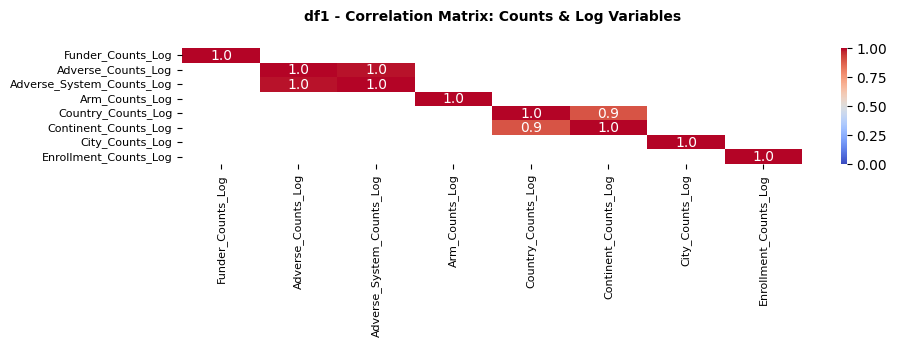

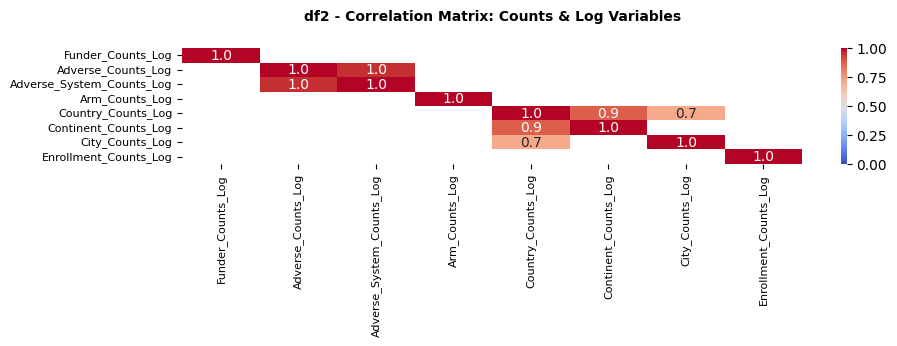

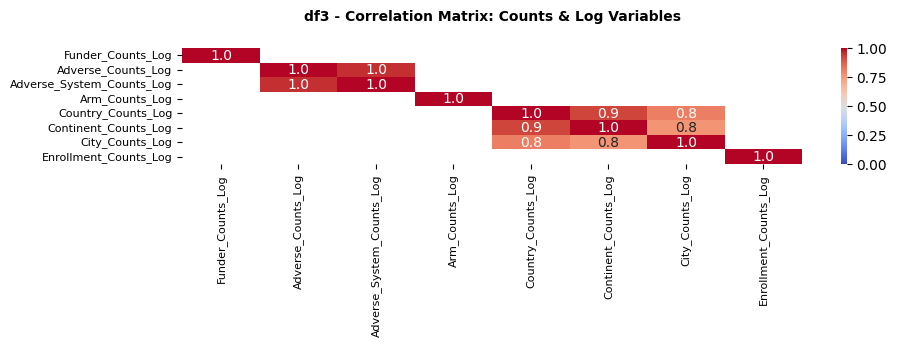

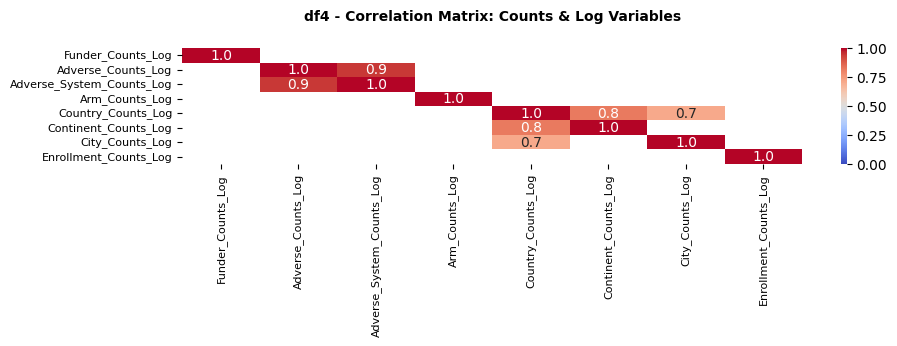

In [97]:
figsize = (10, 1.5)
threshold = 0.7
cont_corr1 = fun_cont_heat(X_train1[[col for col in X_train1.columns if '_Log' in col]], 1, figsize, threshold)
cont_corr2 = fun_cont_heat(X_train2[[col for col in X_train1.columns if '_Log' in col]], 2, figsize, threshold)
cont_corr3 = fun_cont_heat(X_train3[[col for col in X_train1.columns if '_Log' in col]], 3, figsize, threshold)
cont_corr4 = fun_cont_heat(X_train4[[col for col in X_train1.columns if '_Log' in col]], 4, figsize, threshold)

# All _Counts col will be dropped as decided in Thesis_Visual_Train

### Interaction Enrollment

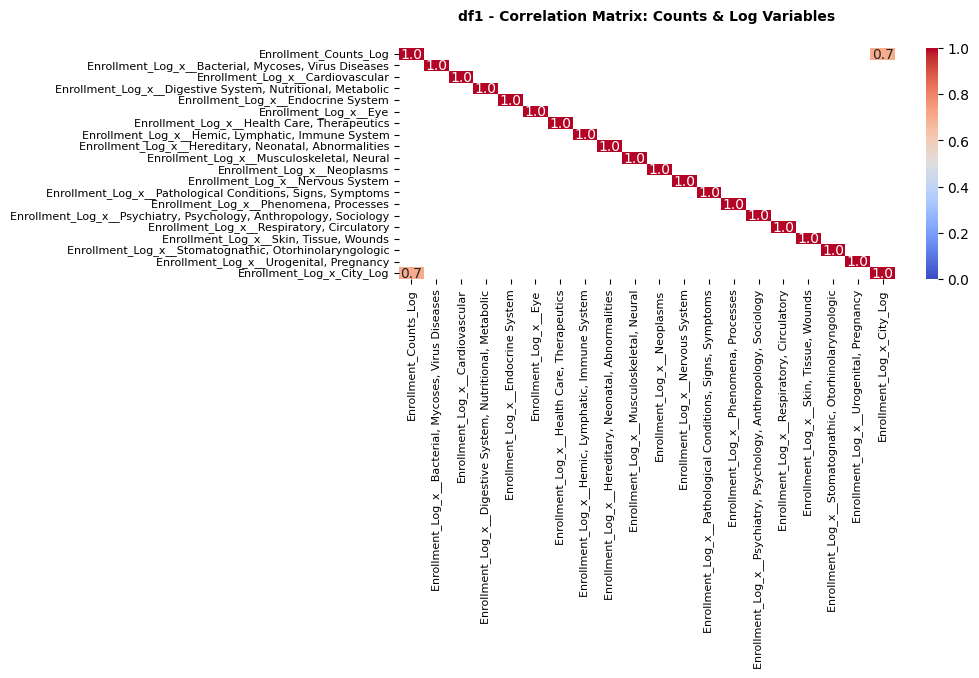

In [104]:
figsize = (8, 3)
threshold = 0.7
cont_corr1 = fun_cont_heat(X_train1_merge[[col for col in X_train1_merge.columns if 'Enrollment' in col]], 1, figsize, threshold)

## Categ x Categ

In [ ]:
# 4 mins --> All dfs give same output regarding correlation
figsize = (30, 30)
threshold = 0.7
categ_corr1 = fun_cramer_heat(
    X_train1, 1, [col for col in X_train1.columns if '_Bin' in col or '_List' in col], figsize, False, threshold)
# categ_corr2 = fun_cramer_heat(X_train2, 2, [col for col in X_train2.columns if '_List' in col], figsize, False, threshold)
# categ_corr3 = fun_cramer_heat(X_train3, 3, [col for col in X_train3.columns if '_List' in col], figsize, False, threshold)
# categ_corr4 = fun_cramer_heat(X_train4, 4, [col for col in X_train4.columns if '_List' in col], figsize, False, threshold)

# categ_cols = [col for col in dfi.columns if '_Categ' in col or '_Bin' in col or '_List' in col]
# All Categ cols will be dropped as decided in Thesis_Visual_Train

KeyboardInterrupt: 

### Conditions

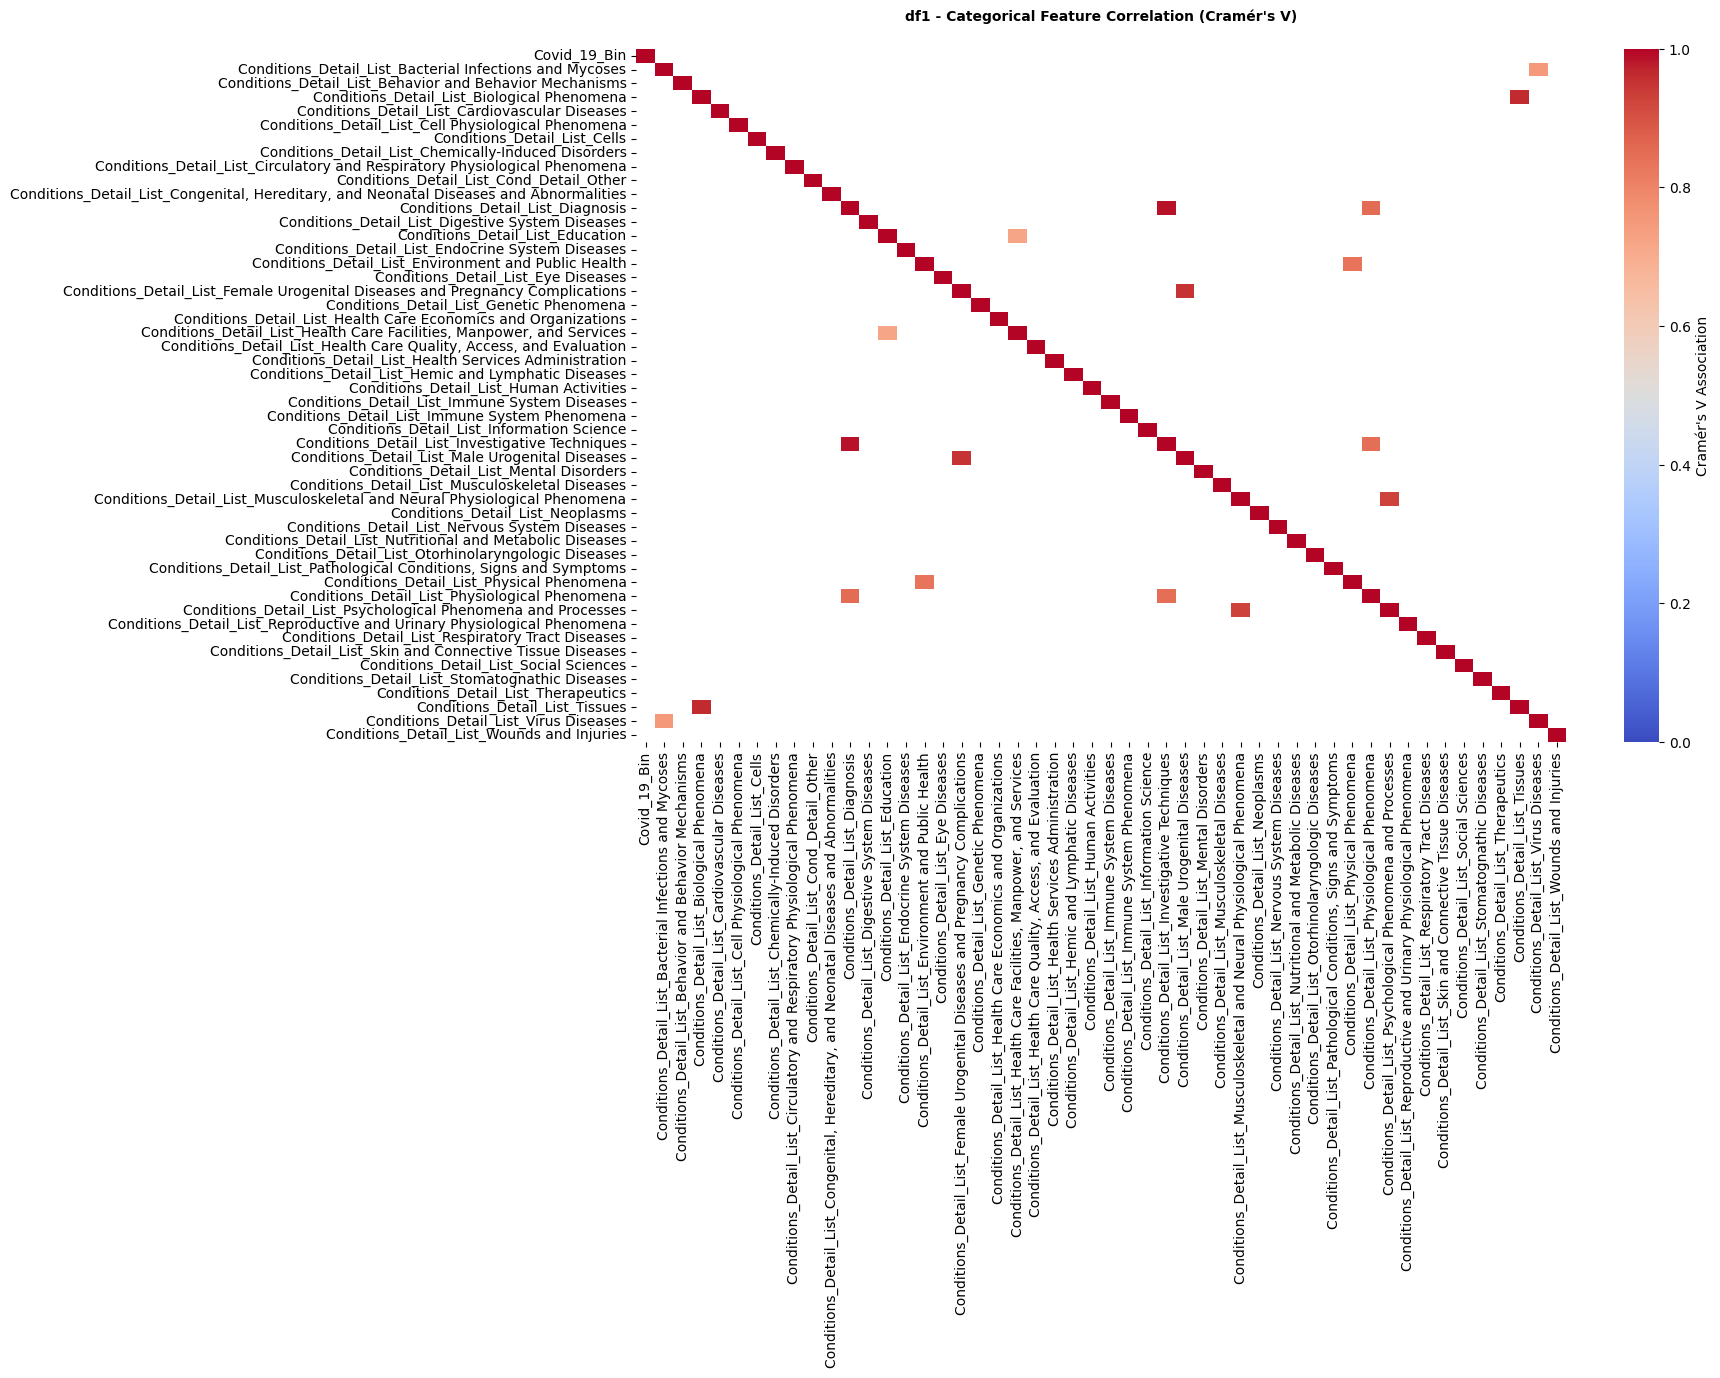

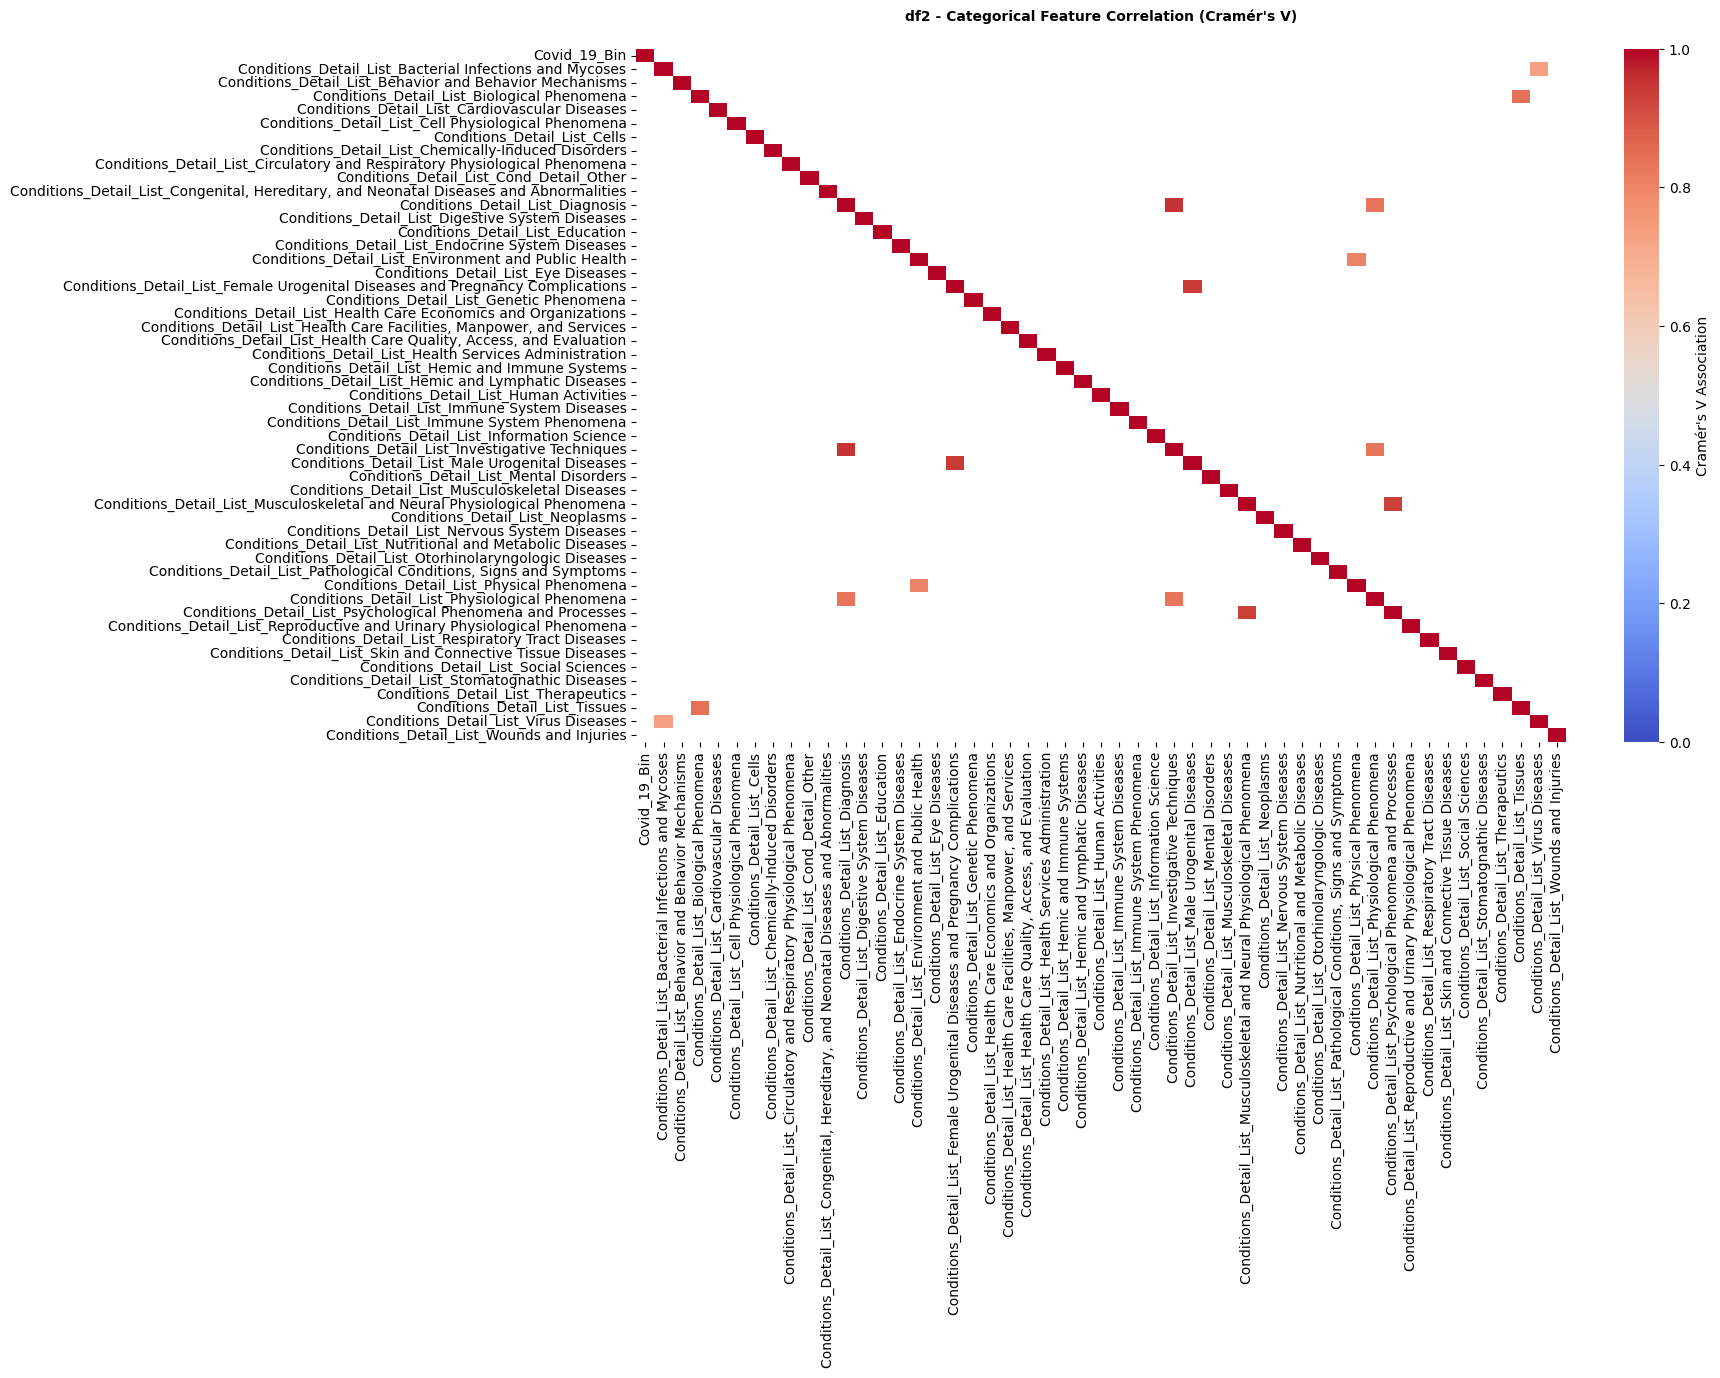

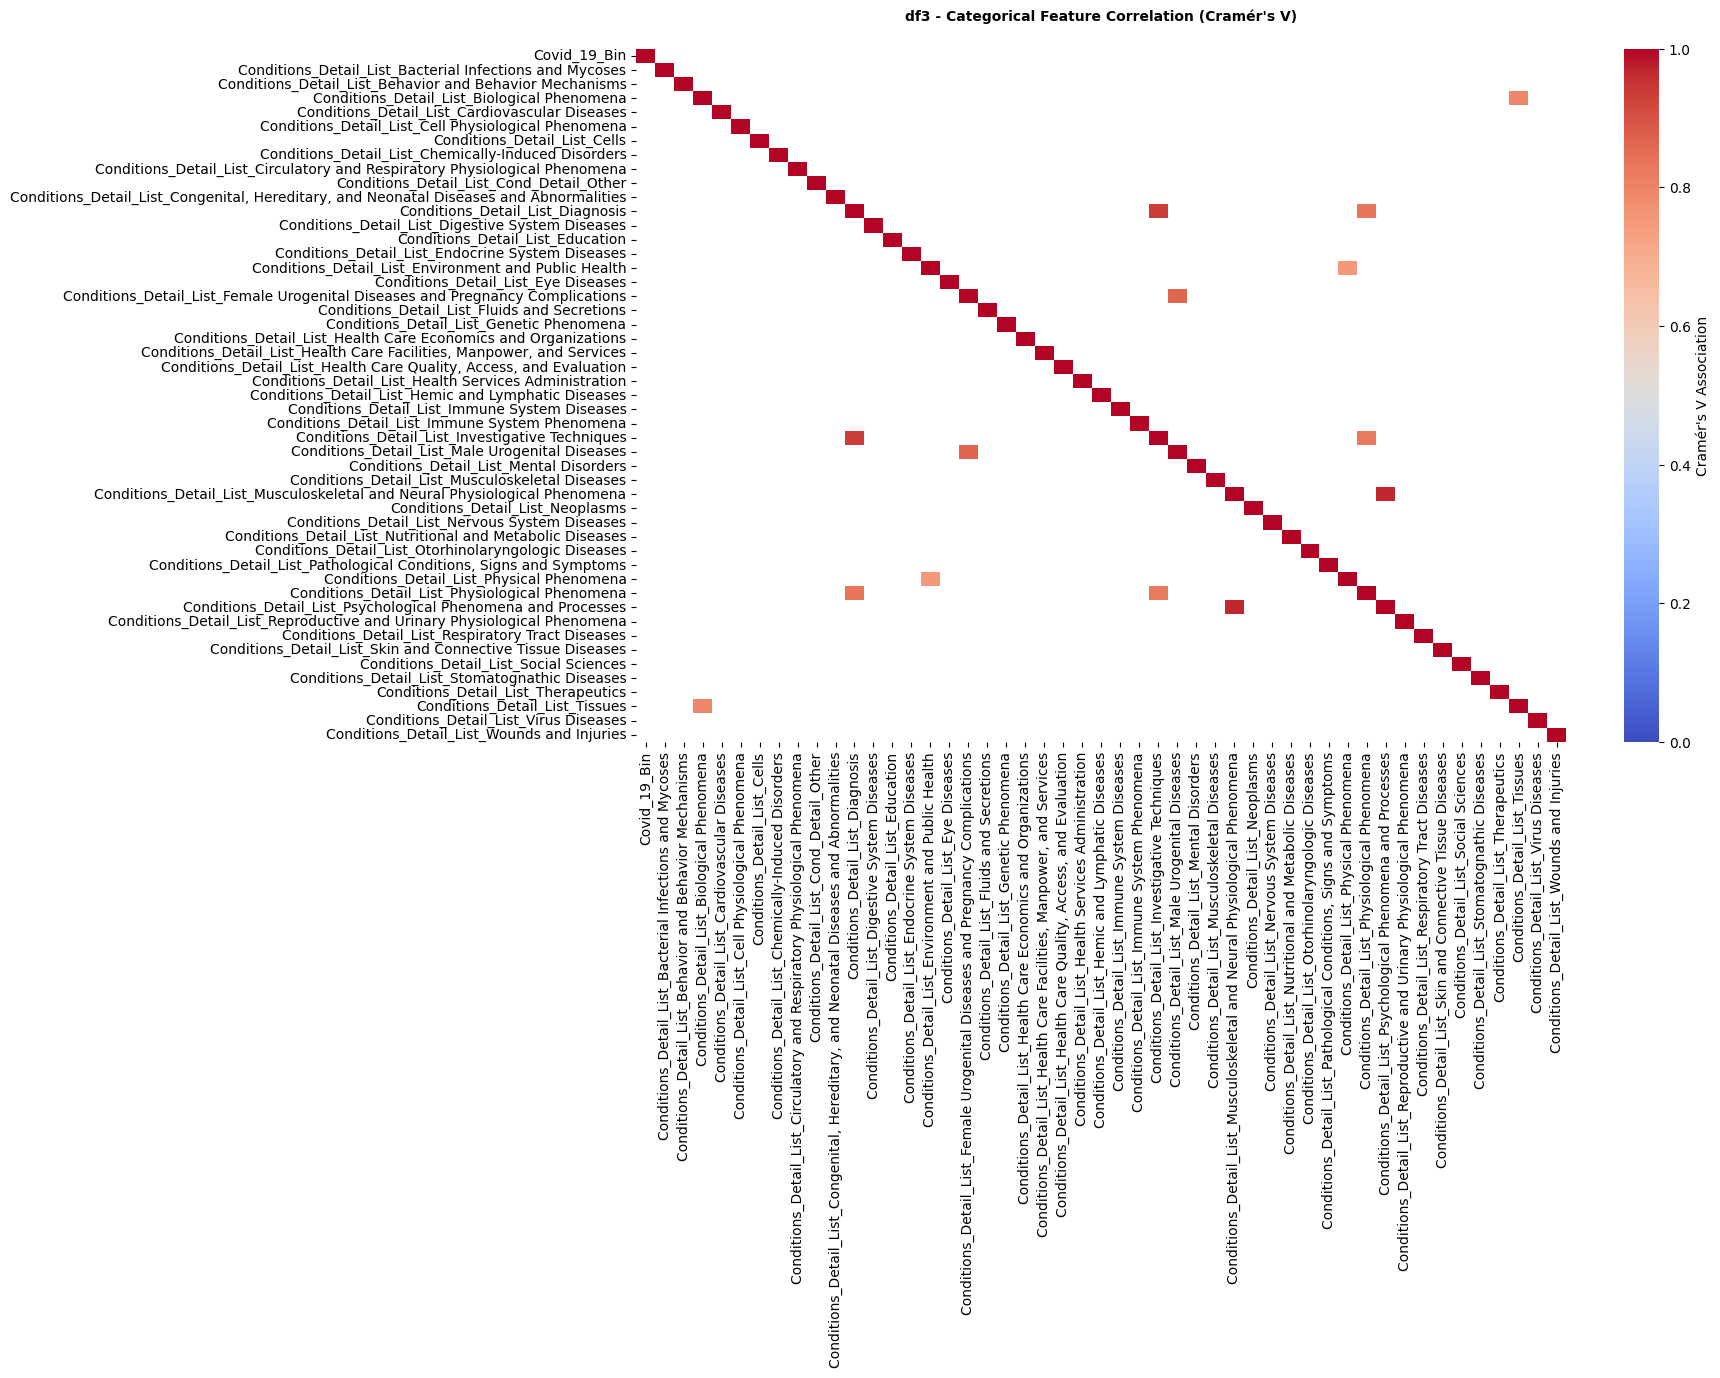

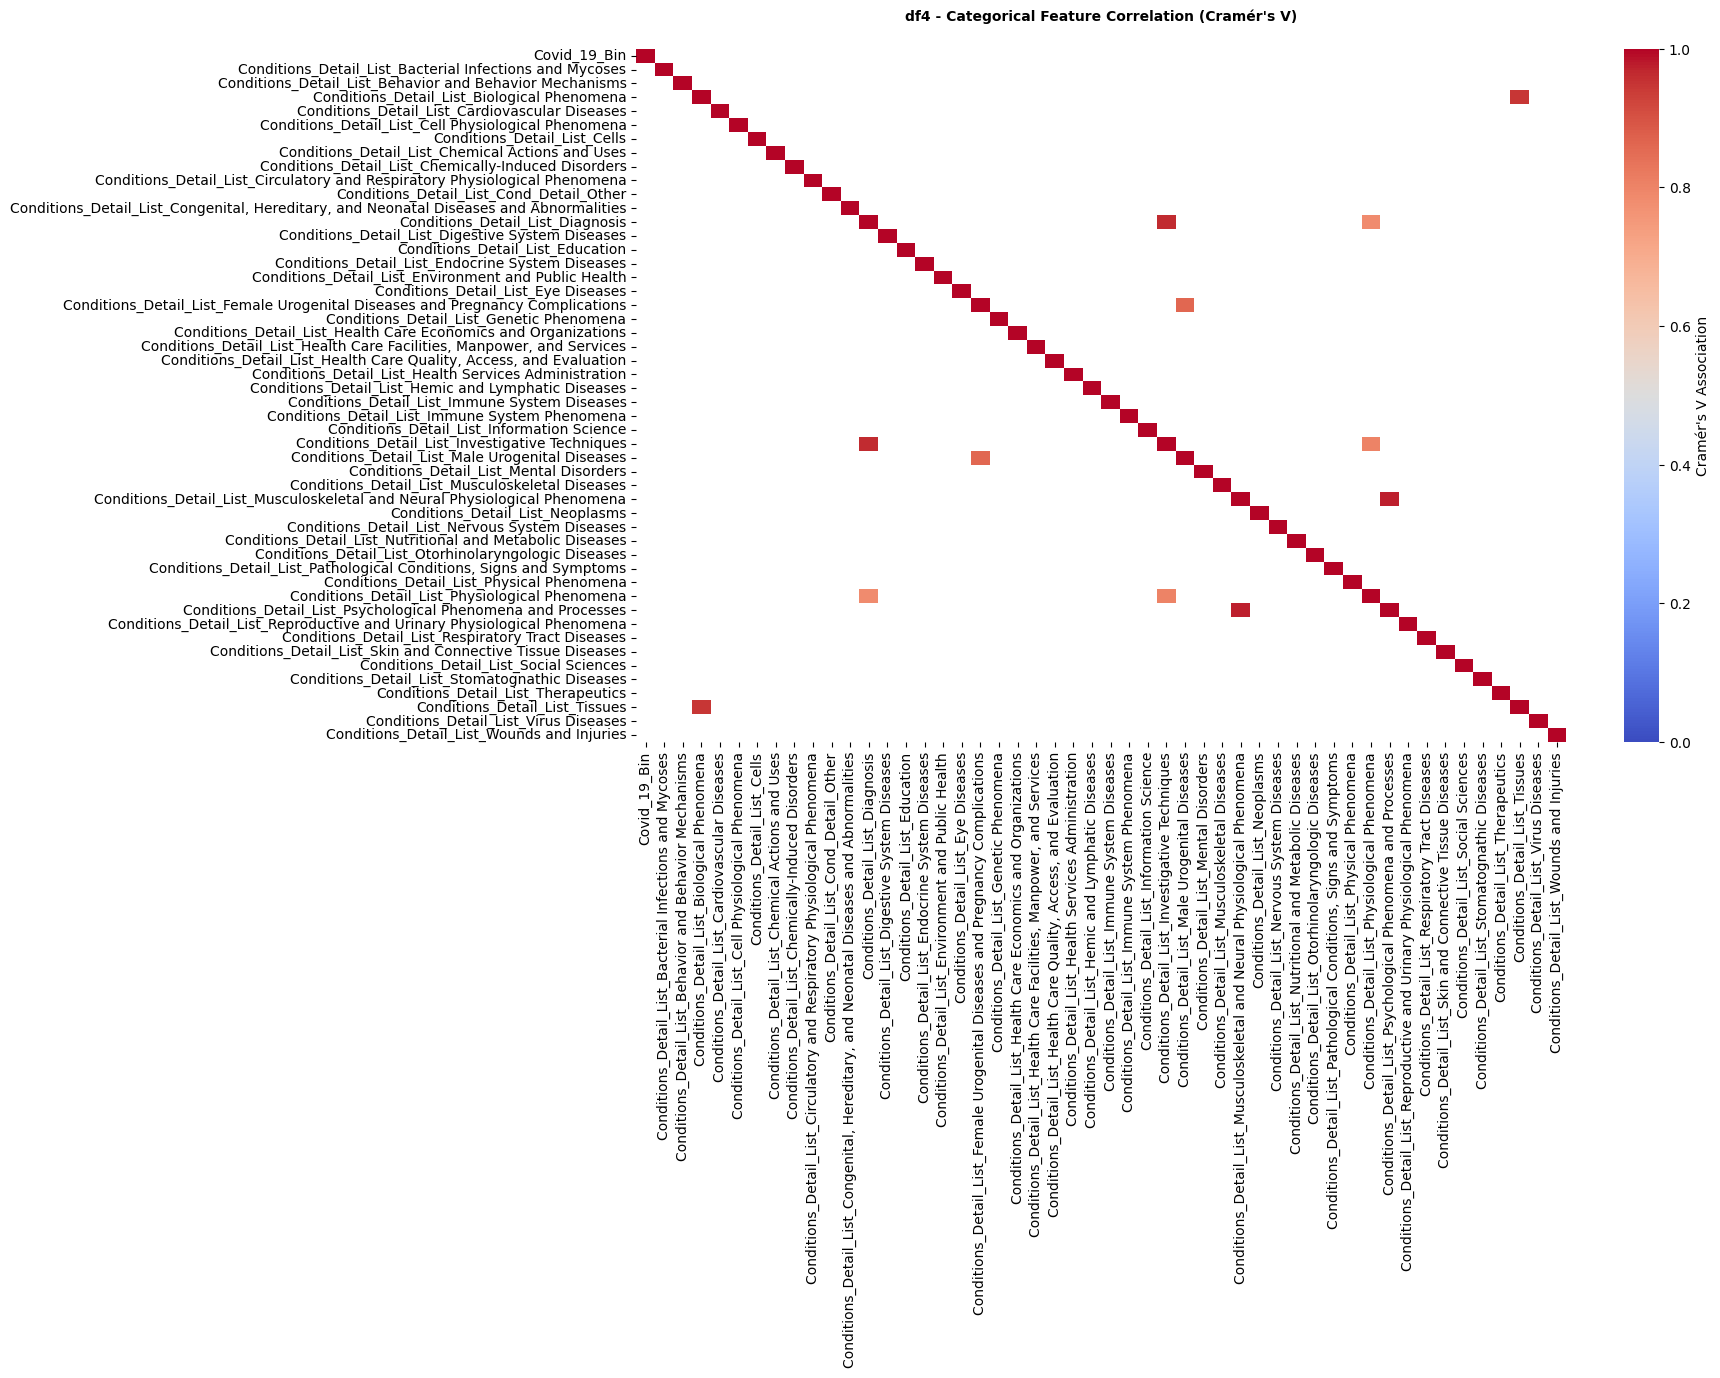

In [110]:
figsize = (15, 9)
threshold = 0.7
cond_categ_corr1 = fun_cramer_heat(X_train1, 1, [col for col in X_train1.columns if 'Conditions' in col or 'Covid' in col], figsize, False, threshold)
cond_categ_corr2 = fun_cramer_heat(X_train2, 2, [col for col in X_train2.columns if 'Conditions' in col or 'Covid' in col], figsize, False, threshold)
cond_categ_corr3 = fun_cramer_heat(X_train3, 3, [col for col in X_train3.columns if 'Conditions' in col or 'Covid' in col], figsize, False, threshold)
cond_categ_corr4 = fun_cramer_heat(X_train4, 4, [col for col in X_train4.columns if 'Conditions' in col or 'Covid' in col], figsize, False, threshold)

### Adverse

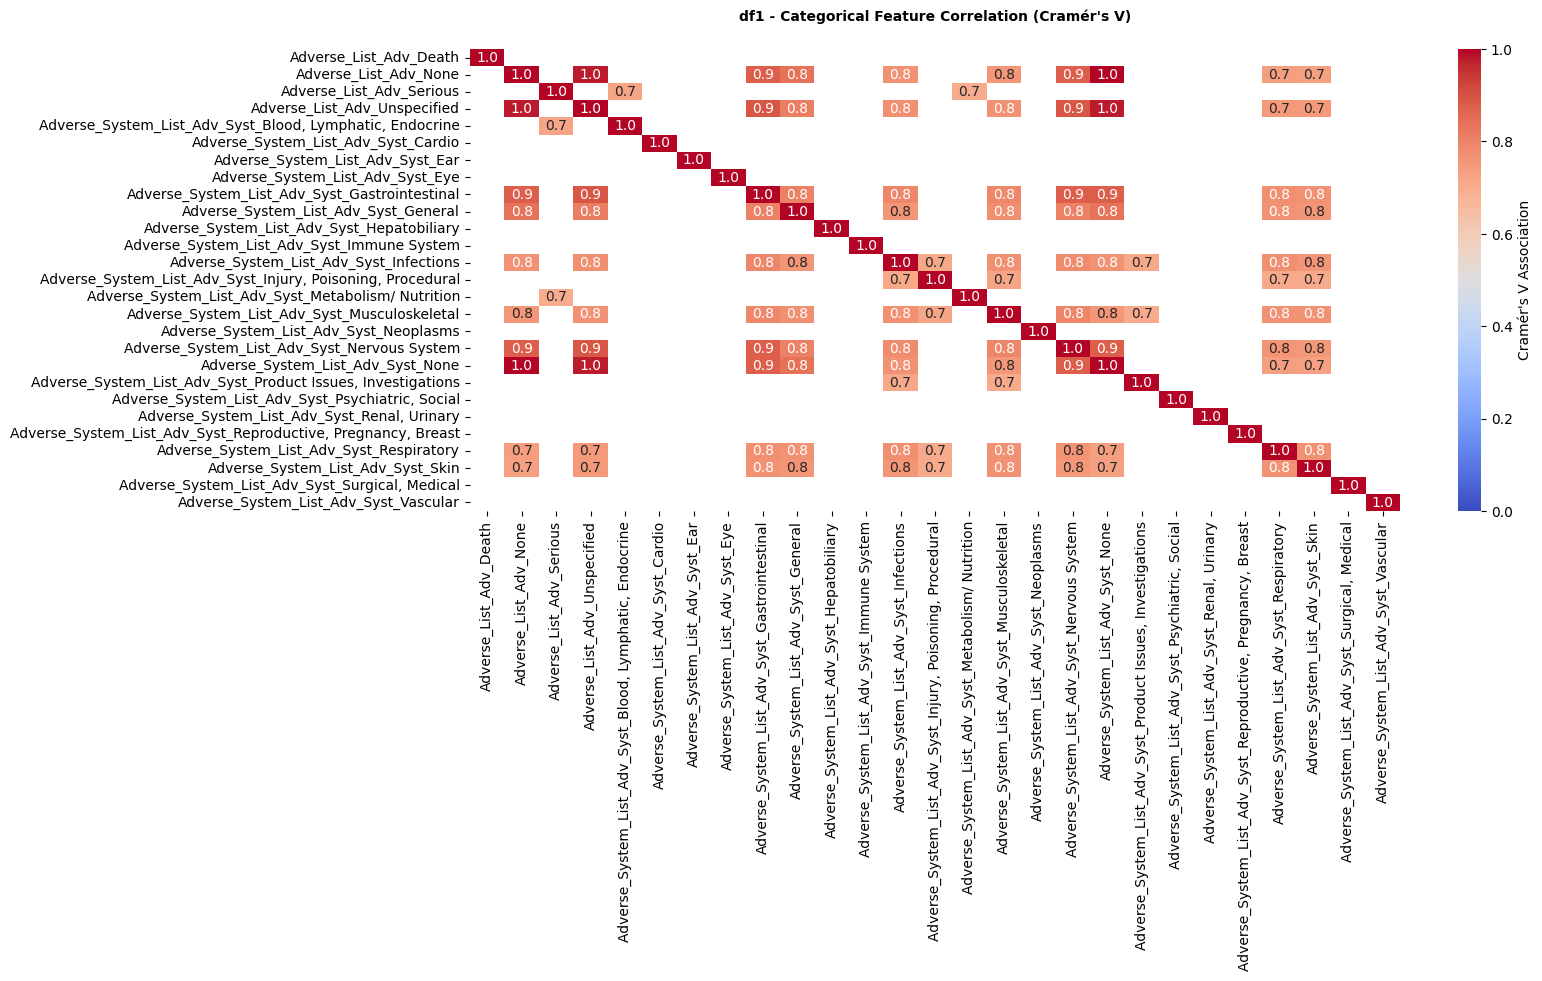

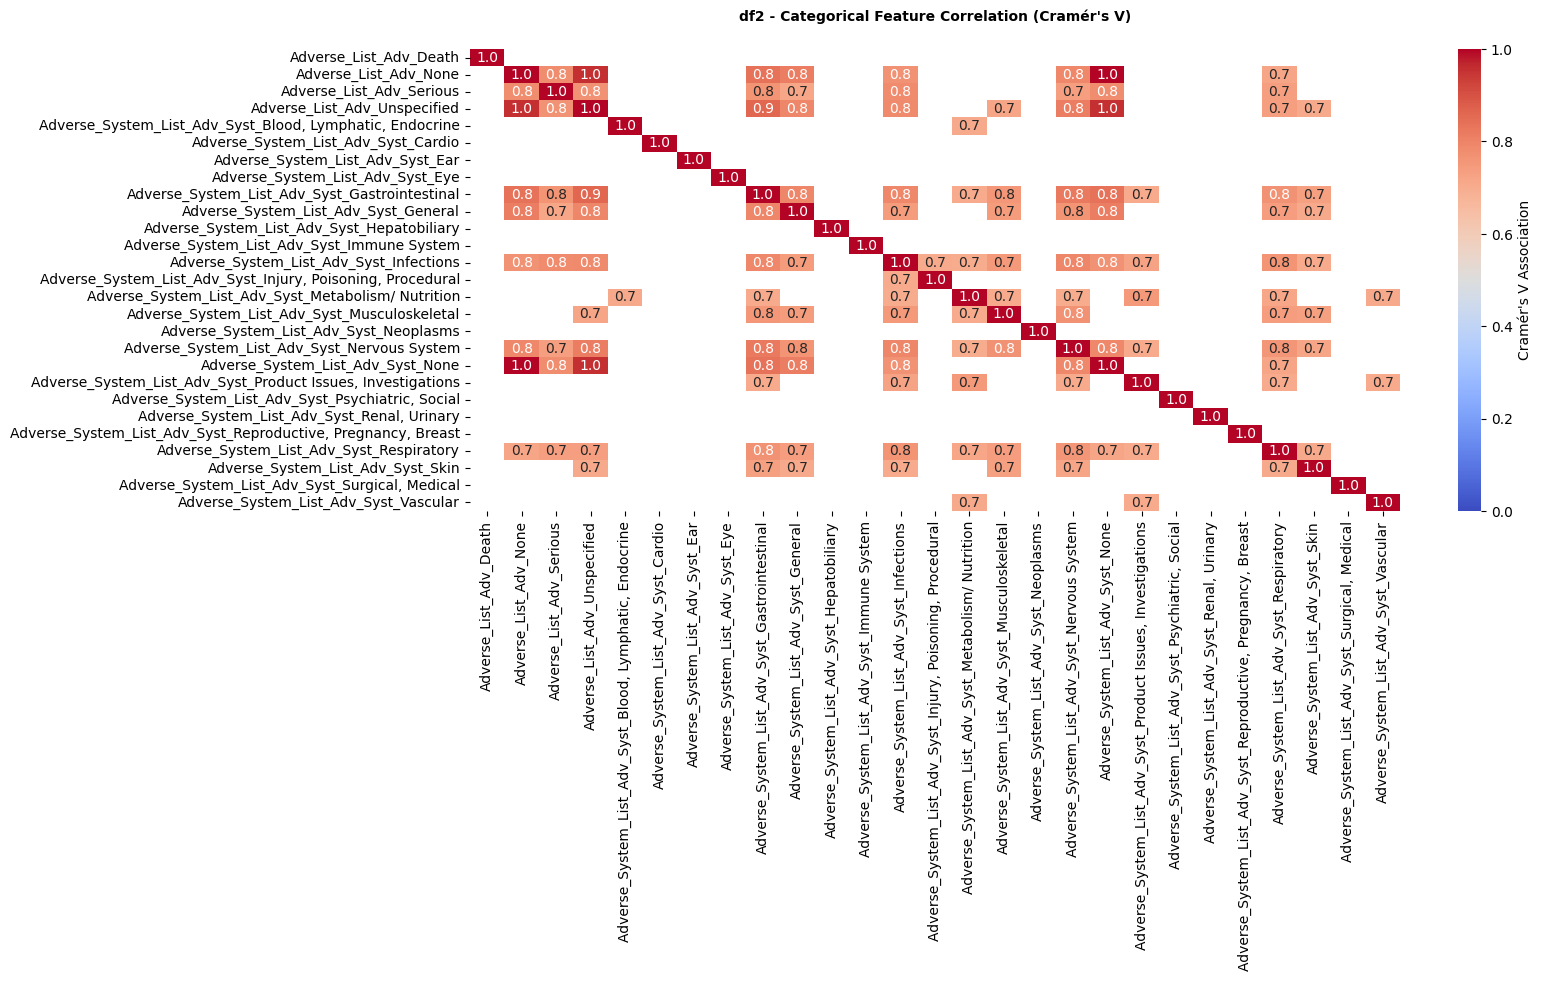

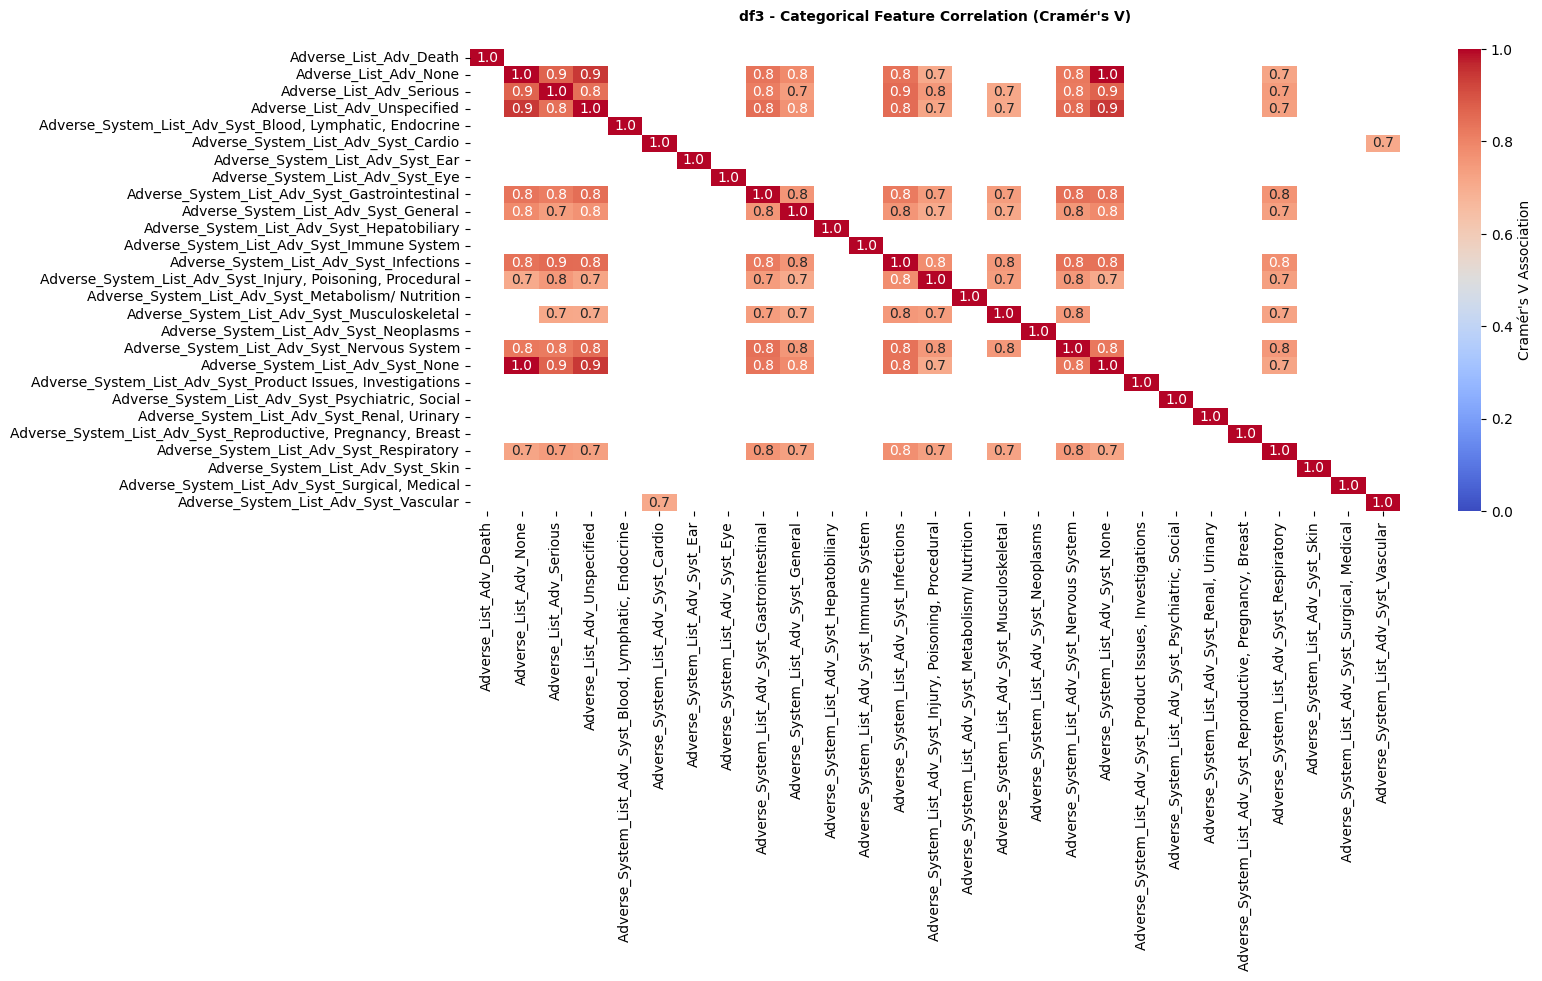

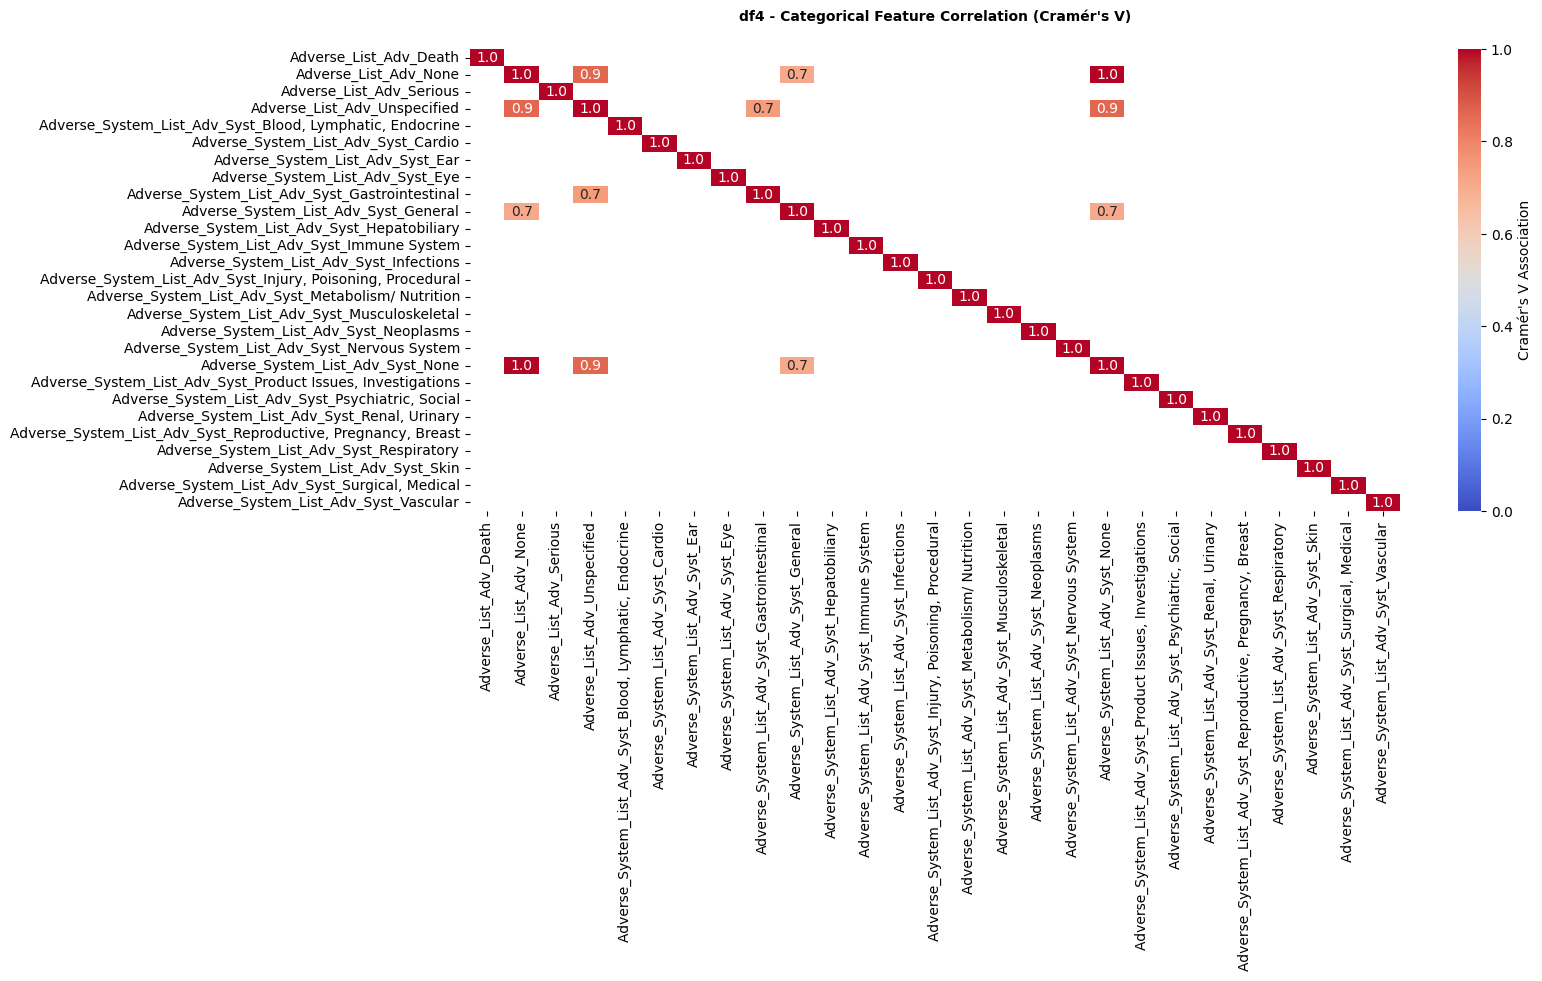

In [ ]:
figsize = (15, 6)
threshold = 0.7
adv_categ_corr1 = fun_cramer_heat(
    X_train1, 1, [col for col in X_train1.columns if 'Adverse' in col and 'List' in col], figsize, True, threshold)
adv_categ_corr2 = fun_cramer_heat(X_train2, 2, [col for col in X_train2.columns if 'Adverse' in col and '_List' in col], figsize, True, threshold)
adv_categ_corr3 = fun_cramer_heat(X_train3, 3, [col for col in X_train3.columns if 'Adverse' in col and '_List' in col], figsize, True, threshold)
adv_categ_corr4 = fun_cramer_heat(X_train4, 4, [col for col in X_train4.columns if 'Adverse' in col and '_List' in col], figsize, True, threshold)

### Masking

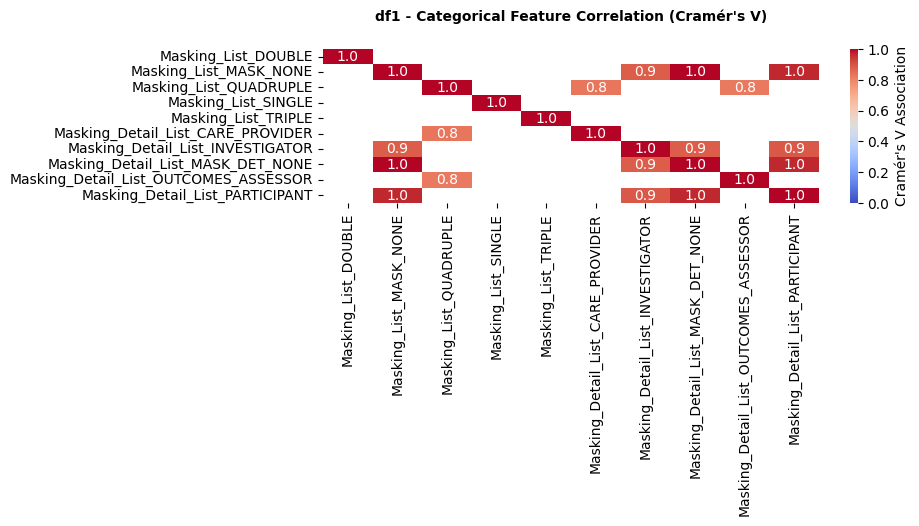

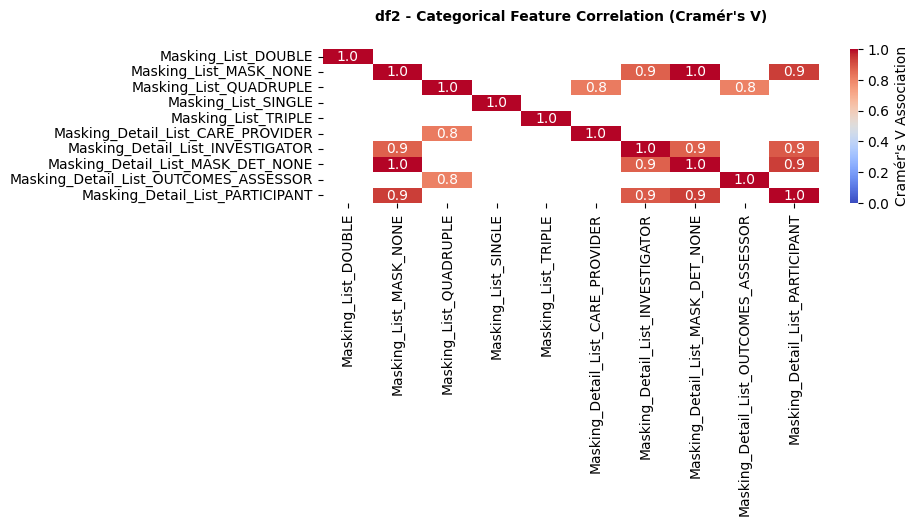

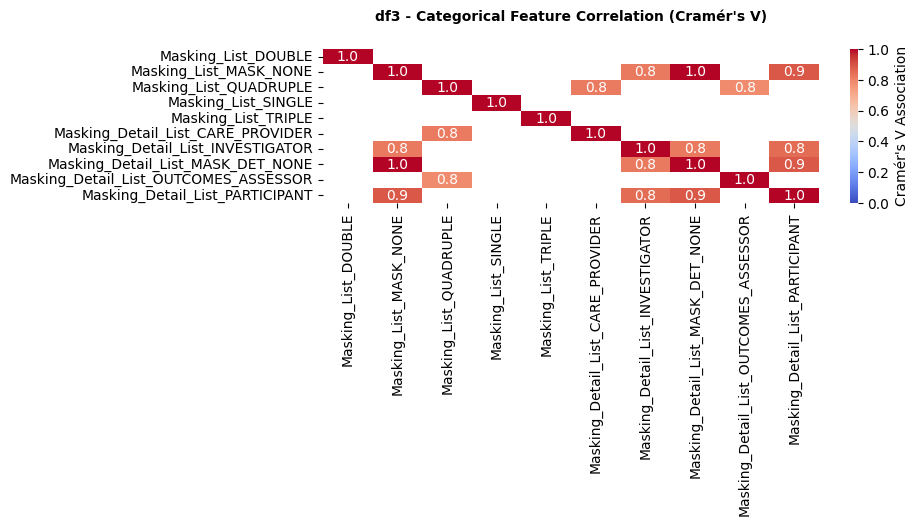

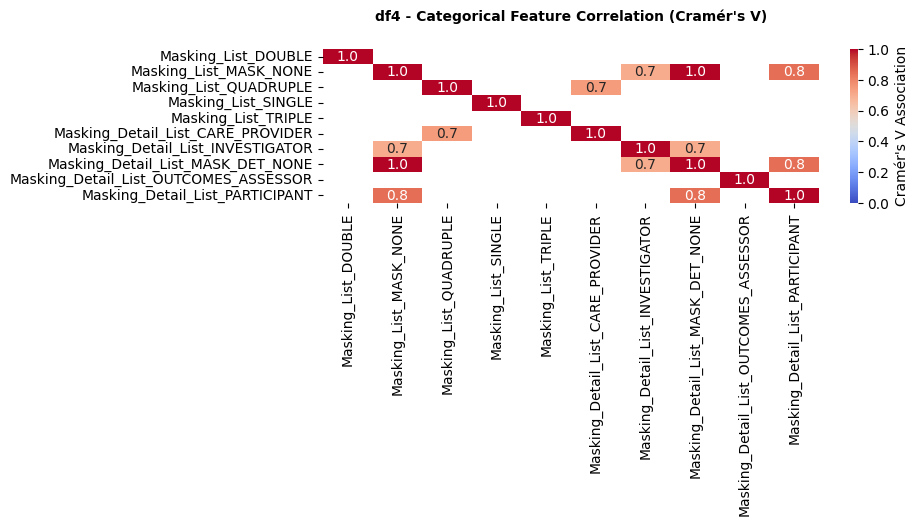

In [ ]:
figsize = (8, 2)
threshold = 0.7
mask_categ_corr1 = fun_cramer_heat(X_train1, 1, [col for col in X_train1.columns if 'Masking' in col], figsize , True, threshold)
mask_categ_corr2 = fun_cramer_heat(X_train2, 2, [col for col in X_train2.columns if 'Masking' in col], figsize , True, threshold)
mask_categ_corr3 = fun_cramer_heat(X_train3, 3, [col for col in X_train3.columns if 'Masking' in col], figsize , True, threshold)
mask_categ_corr4 = fun_cramer_heat(X_train4, 4, [col for col in X_train4.columns if 'Masking' in col], figsize , True, threshold)

### Primary Purpose

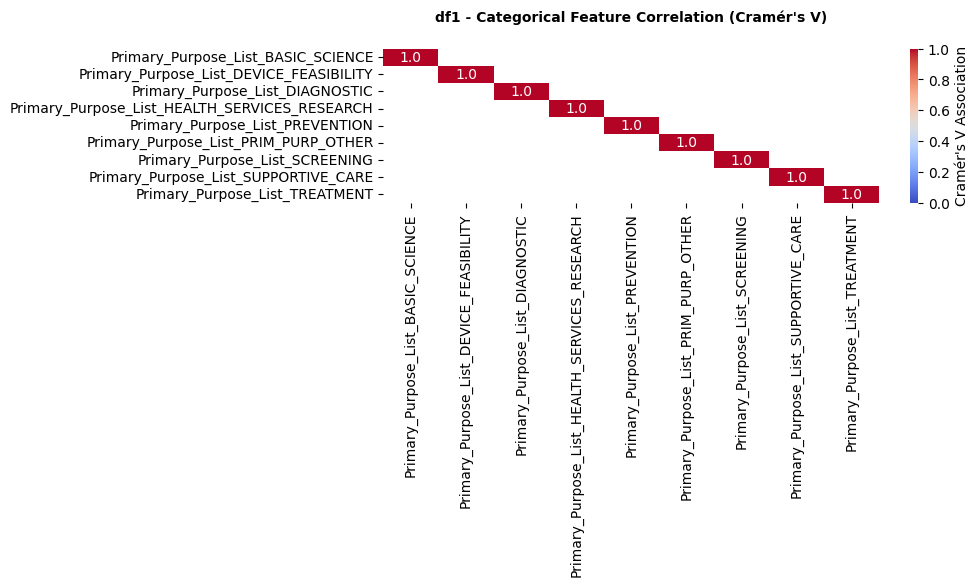

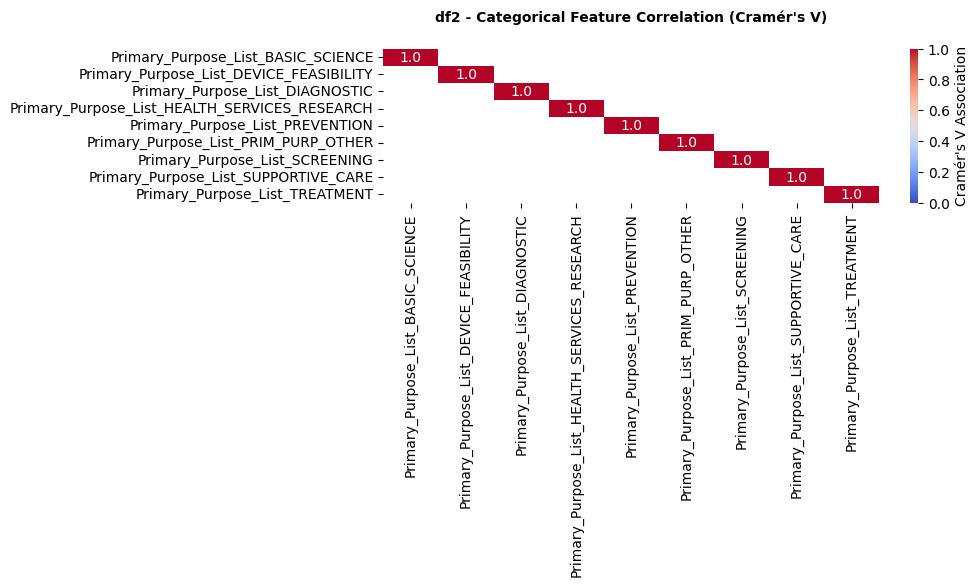

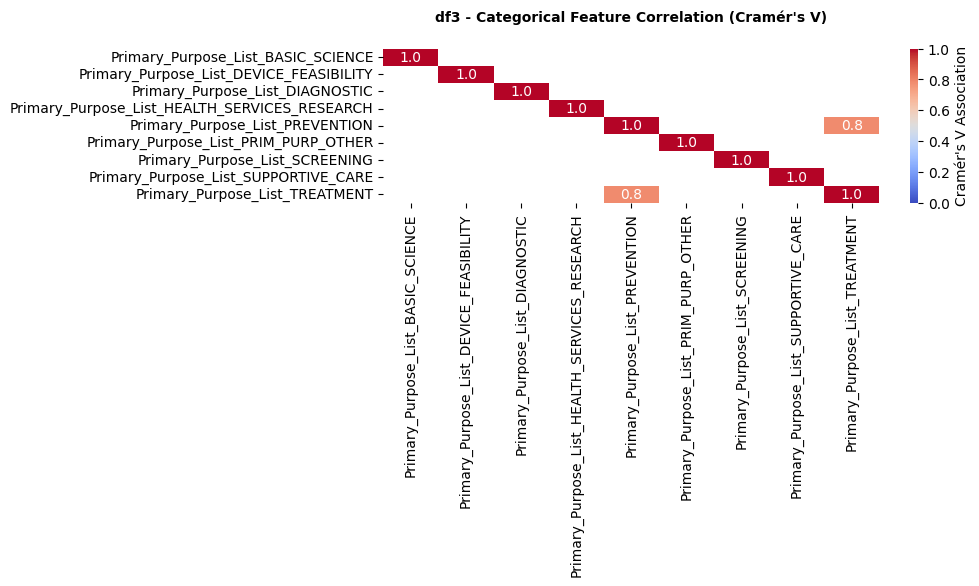

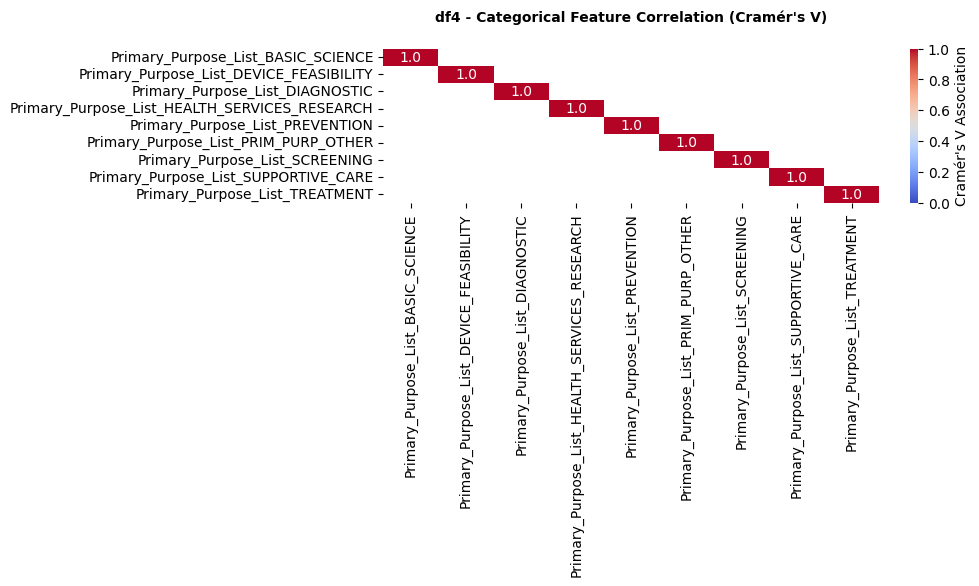

In [ ]:
figsize = (8, 2)
threshold = 0.7
purp_categ_corr1 = fun_cramer_heat(X_train1, 1, [col for col in X_train1.columns if 'Primary' in col],figsize , True, threshold)
purp_categ_corr2 = fun_cramer_heat(X_train2, 2, [col for col in X_train2.columns if 'Primary' in col],figsize , True, threshold)
purp_categ_corr3 = fun_cramer_heat(X_train3, 3, [col for col in X_train3.columns if 'Primary' in col],figsize , True, threshold)
purp_categ_corr4 = fun_cramer_heat(X_train4, 4, [col for col in X_train4.columns if 'Primary' in col],figsize , True, threshold)

### Intervention_Type

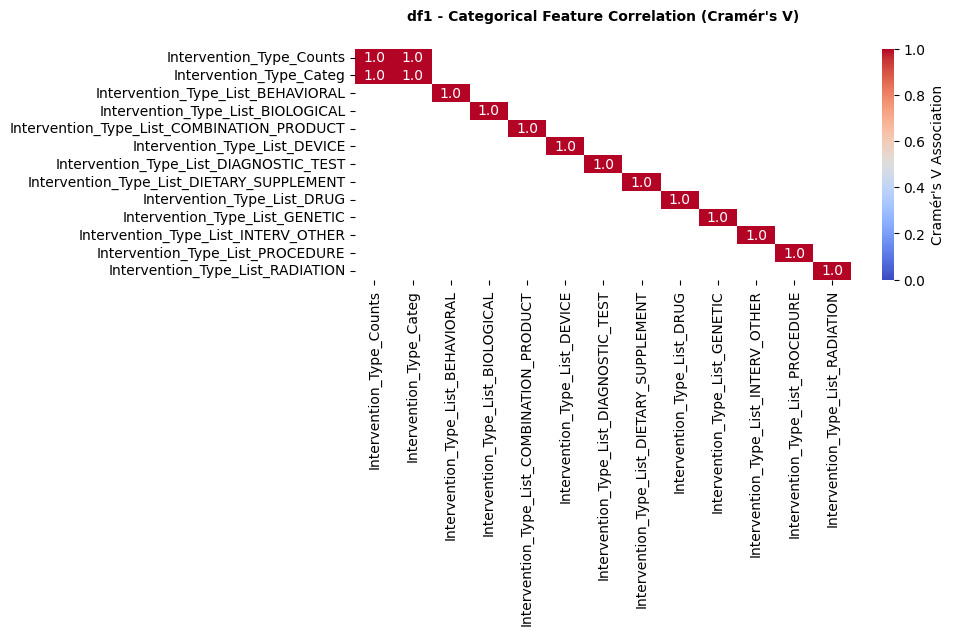

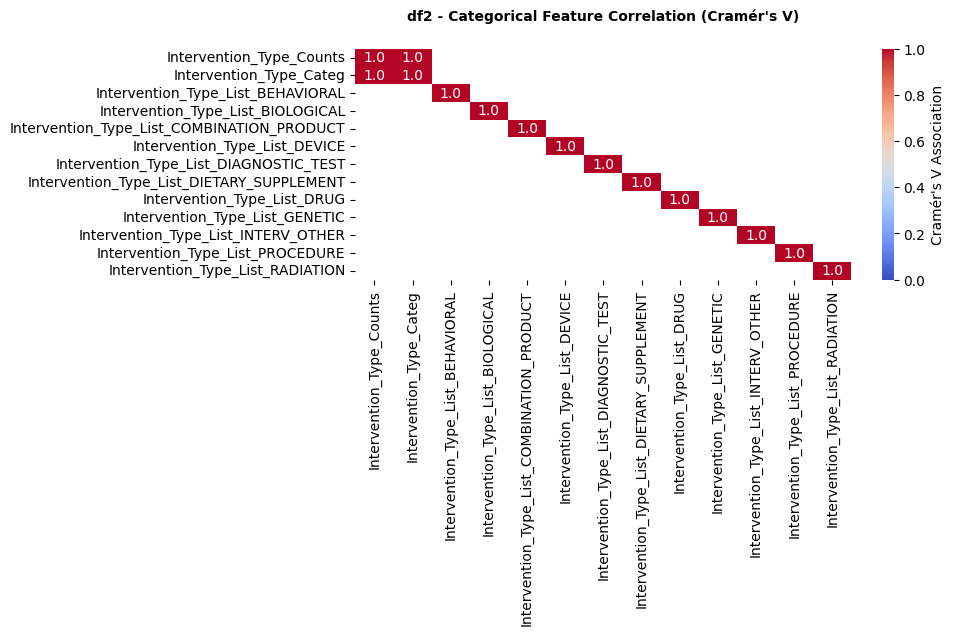

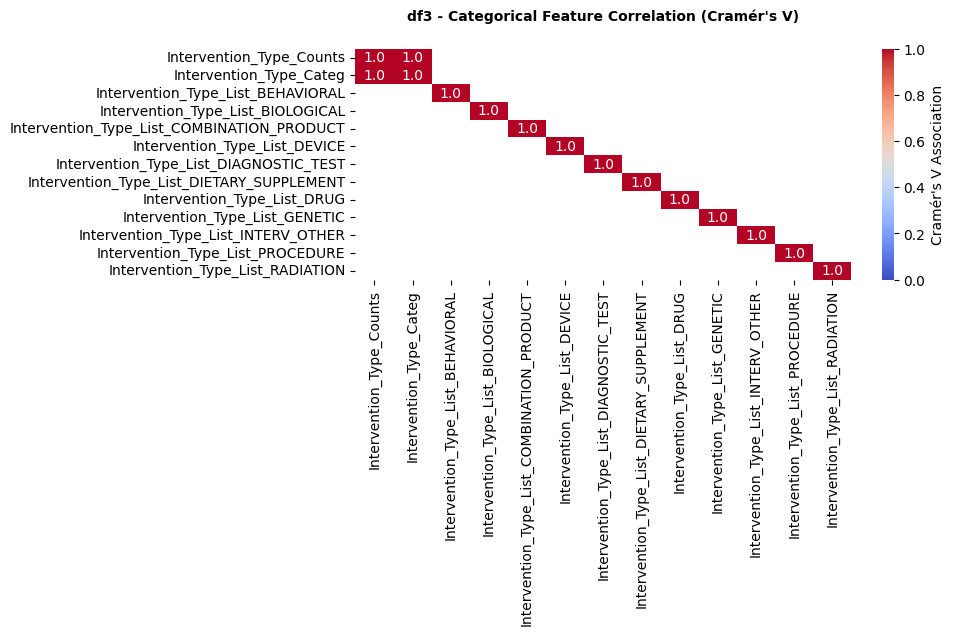

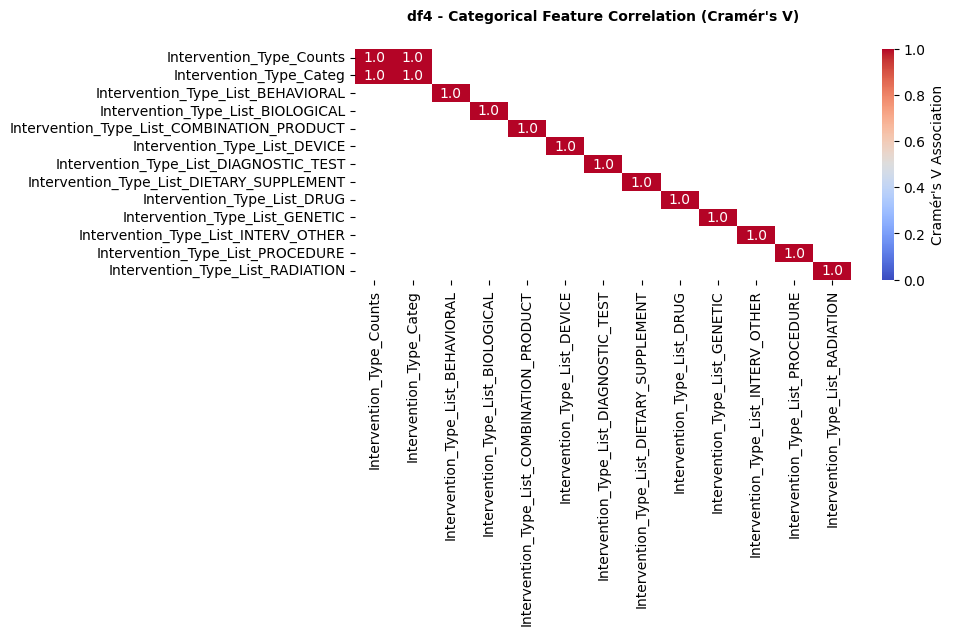

In [ ]:
figsize = (8, 3)
threshold = 0.7
inter_categ_corr1 = fun_cramer_heat(X_train1, 1, [col for col in X_train1.columns if 'Intervention_Type' in col],figsize , True, threshold)
inter_categ_corr2 = fun_cramer_heat(X_train2, 2, [col for col in X_train2.columns if 'Intervention_Type' in col],figsize , True, threshold)
inter_categ_corr3 = fun_cramer_heat(X_train3, 3, [col for col in X_train3.columns if 'Intervention_Type' in col],figsize , True, threshold)
inter_categ_corr4 = fun_cramer_heat(X_train4, 4, [col for col in X_train4.columns if 'Intervention_Type' in col],figsize , True, threshold)

## Categ x Continues


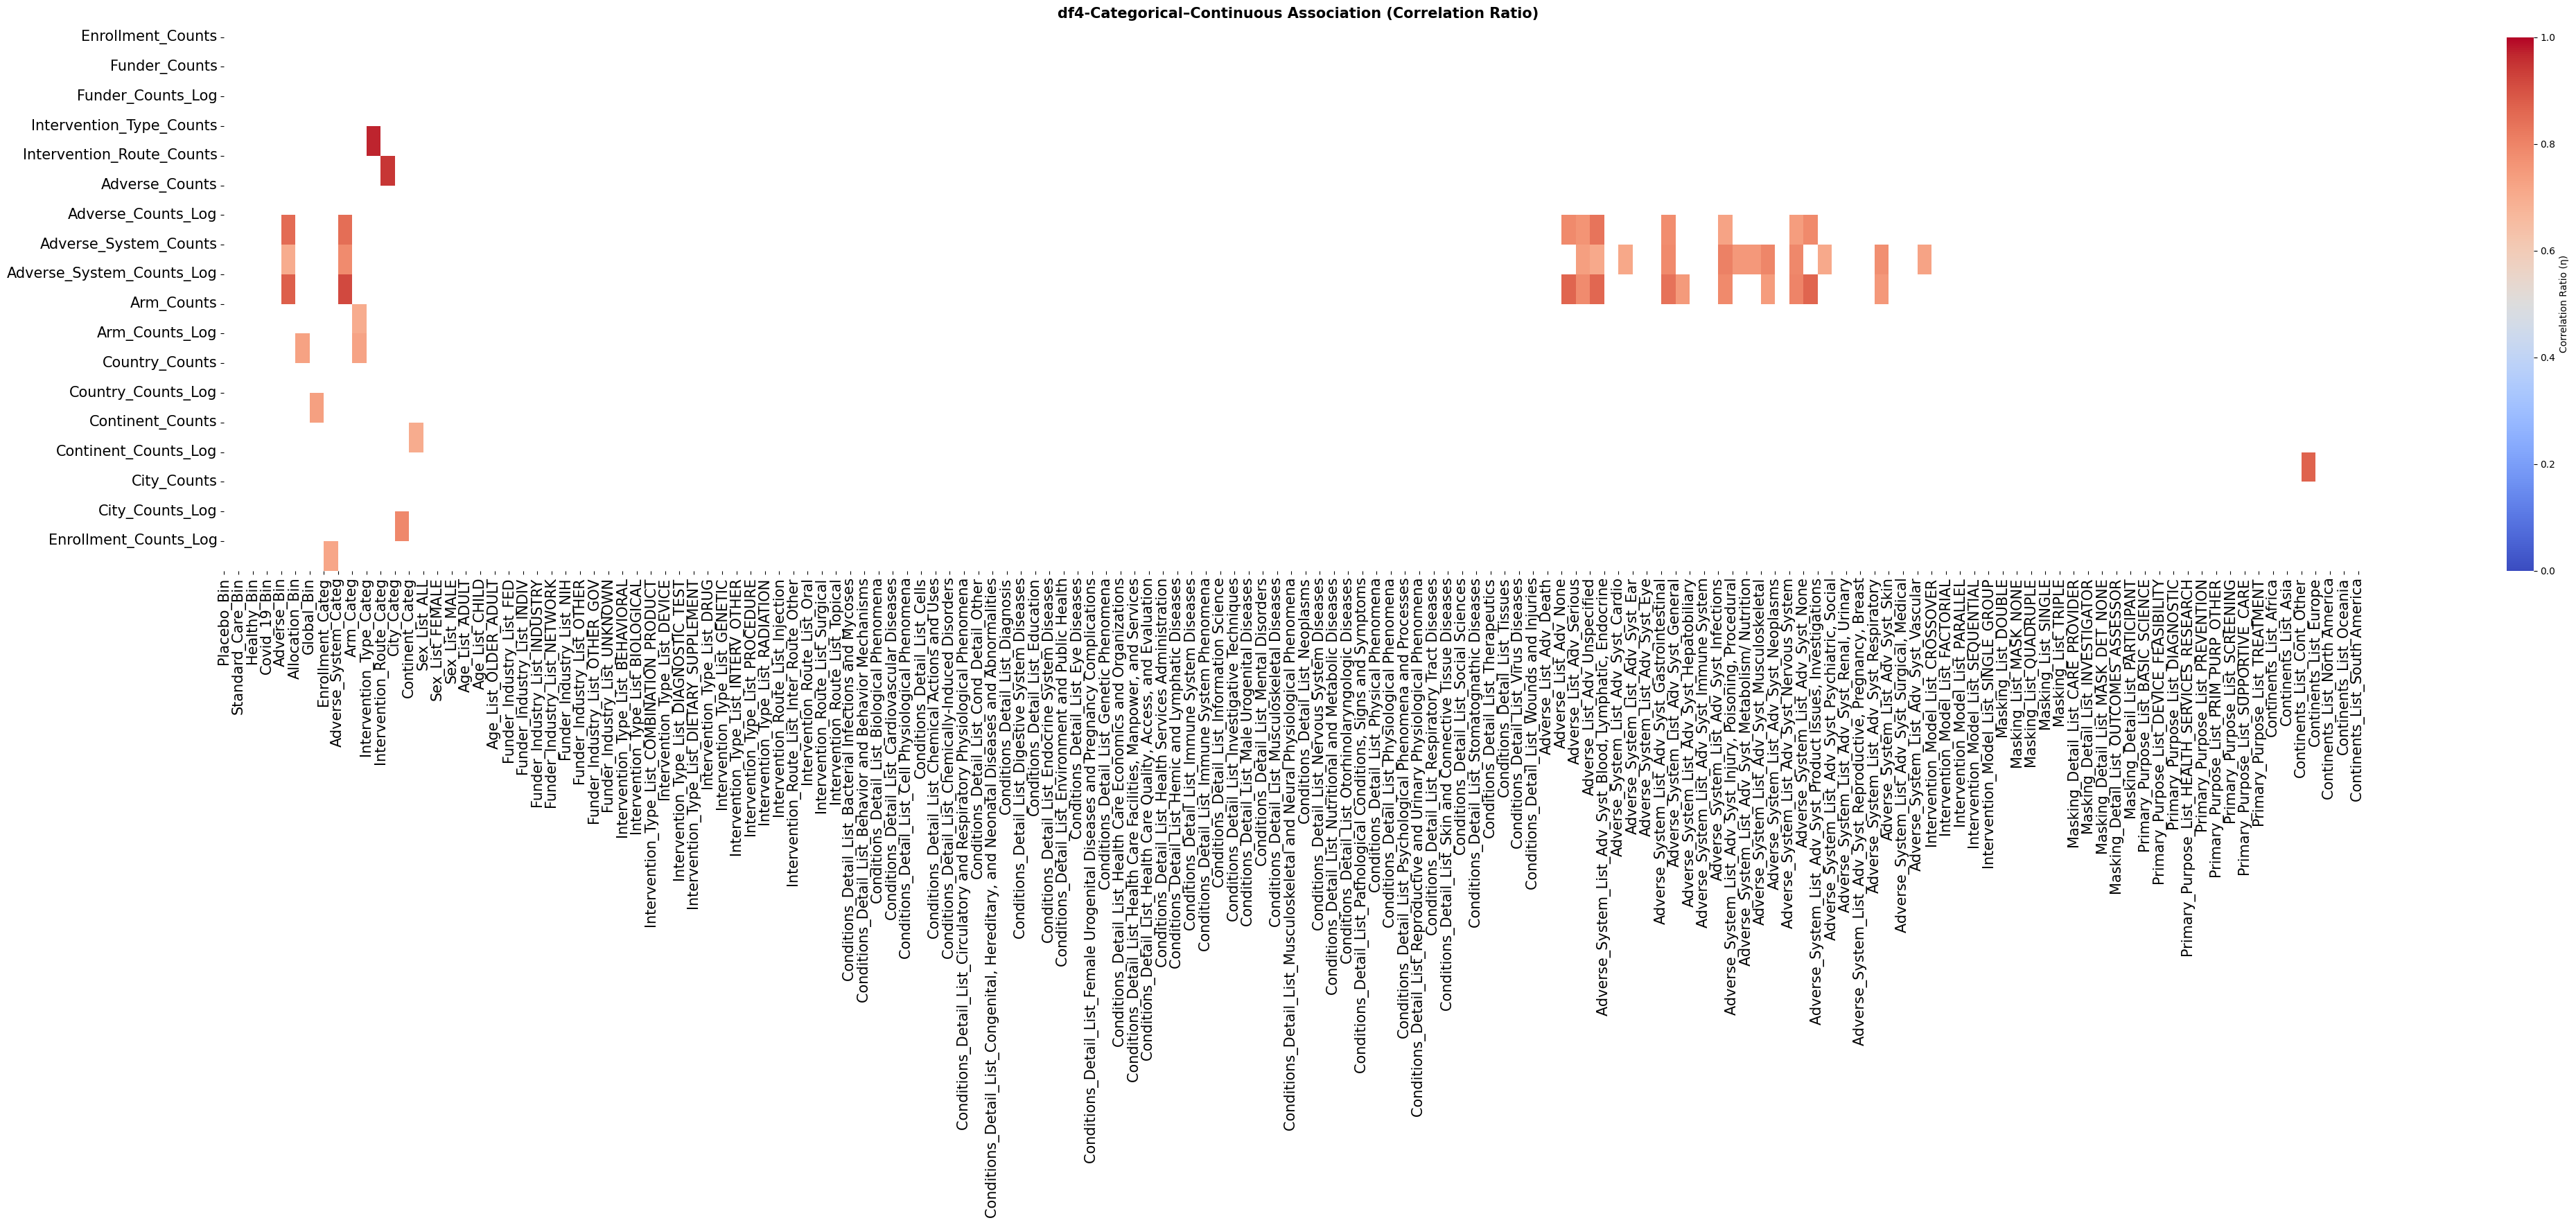

In [65]:
figsize = (50, 10)
threshold = 0.7
dfi = X_train4
i= 4
categ_cont_corr1 = fun_anova(dfi, i, 
    categ_cols = [col for col in dfi.columns if '_Categ' in col or '_Bin' in col or '_List' in col], 
    cont_cols = [col for col in dfi.columns if '_Log' in col or '_Counts' in col], annot = False, 
    figsize = figsize, threshold = threshold)                  

### Adverse

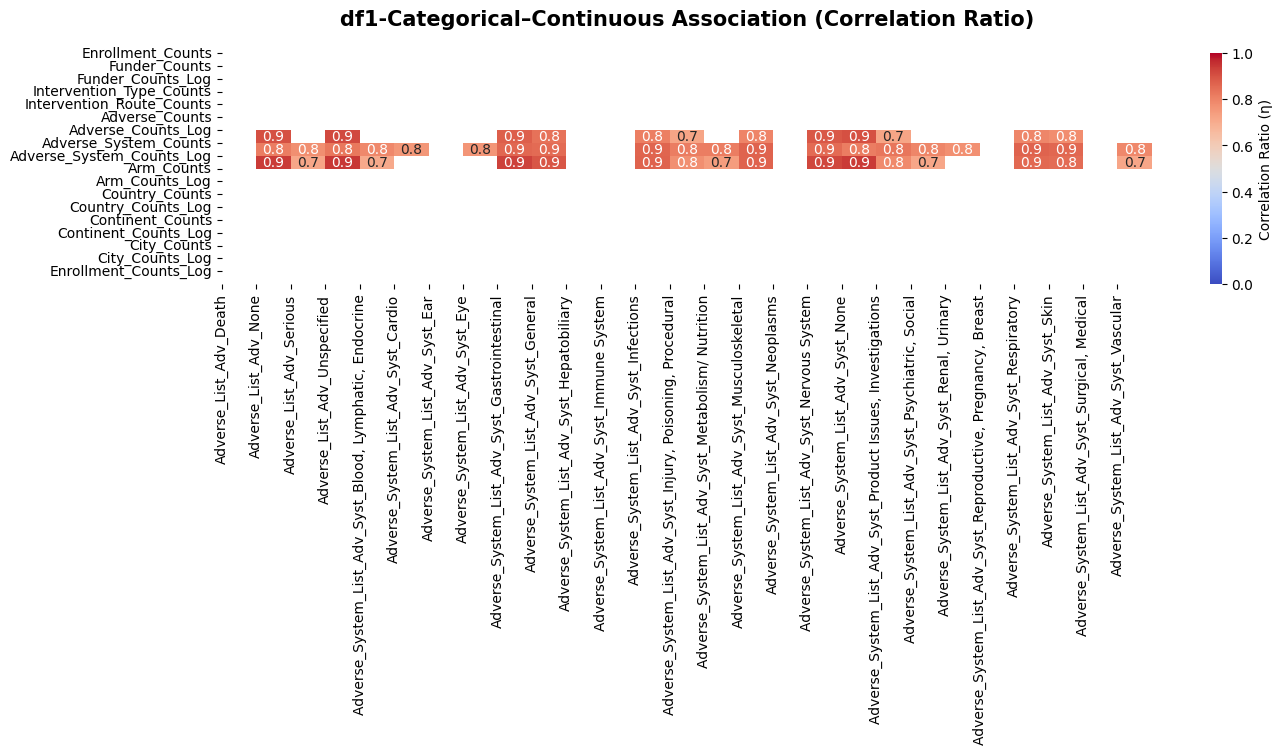

In [ ]:
figsize = (15, 3)
threshold = 0.7
categ_cont_corr1 = fun_anova(X_train1, 1, 
    categ_cols = [col for col in X_train1.columns if 'Adverse' in col and '_List' in col], 
    cont_cols = [col for col in X_train1.columns if '_Log' in col or '_Counts' in col], annot = True, figsize = figsize, 
    threshold = threshold)

# Models

## Function

In [22]:
def fun_aic(X, y, i, cont, display_log=False):
# Model 
    if cont:
        X = sm.add_constant(X) # continuous features always add constant else LLR = nan. Nothing to compare the coeff.
        model = sm.Logit(y, X)
    else:
        X = sm.add_constant(X)
        X = X.drop(X.columns[1], axis=1)  # Drop first column after adding constant to avoid multicollinearity
        model = sm.Logit(y, X) 
    
    results = model.fit(method = 'lbfgs', maxiter = 1000)

    if display_log == True:
        print(results.summary())
# AIC
    aic = round(results.aic, 0)  # AIC test in case needed for comparison
    return aic

## Adverse

In [25]:
X = X_train1[[col for col in X_train1.columns if 'Adverse_List' in col]]
aic_adv_list = fun_aic(X, y_train1, 1, False, False)
display(f'AIC Adverse_List: {aic_adv_list}')

X = X_train1[[col for col in X_train1.columns if 'Adverse_System_List' in col]]
aic_adv_syst = fun_aic(X, y_train1, 1, False, False)
display(f'AIC Adverse_System_List: {aic_adv_syst}')


'AIC Adverse_List: 14432.0'

'AIC Adverse_System_List: 14389.0'

## Masking

In [24]:
X = X_train1[[col for col in X_train1.columns if 'Masking_List' in col]]
aic_mask = fun_aic(X, y_train1, 1, False, False)
display(f'AIC Masking_List: {aic_mask}')

X = X_train1[[col for col in X_train1.columns if 'Masking_Detail' in col]]
aic_mask_det = fun_aic(X, y_train1, 1, False, False)
display(f'AIC Masking_Detail: {aic_mask_det}')

'AIC Masking_List: 14384.0'

'AIC Masking_Detail: 14386.0'

## Locations

In [ ]:
X = X_train1['City_Counts_Log']
aic_cities = fun_aic(X, y_train1, 1, True, False)
display(f'AIC Cities_Counts_Log: {aic_cities}')

X = X_train1['Country_Counts_Log']
aic_countries = fun_aic(X, y_train1, 1, True, False)
display(f'AIC Countries_Counts_Log: {aic_countries}')

'AIC Cities_Counts_Log: 14430.0'

'AIC Countries_Counts_Log: 14510.0'

## Enrollment

In [109]:
X = X_train1_merge['Enrollment_Counts_Log']
aic_enroll = fun_aic(X, y_train1_merge, 1, True, False)
display(f'AIC Enrollment_Counts_Log: {aic_enroll}')

X = X_train1_merge[[col for col in X_train1_merge.columns if 'Enrollment_x_City' in col]]
aic_cenroll_city = fun_aic(X, y_train1_merge, 1, True, False)
display(f'AIC Enrollment_x_City: {aic_cenroll_city}')

X = X_train1_merge[[col for col in X_train1_merge.columns if 'Enrollment_Log_x_City' in col or 'Enrollment_Counts_Log' in col]]
aic_cenroll_all = fun_aic(X, y_train1_merge, 1, True, True)
display(f'AIC Enrollment_x_City: {aic_cenroll_all}')

'AIC Enrollment_Counts_Log: 10812.0'

'AIC Enrollment_x_City: 14508.0'

                           Logit Regression Results                           
Dep. Variable:       Study_Status_Bin   No. Observations:                17463
Model:                          Logit   Df Residuals:                    17460
Method:                           MLE   Df Model:                            2
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                  0.3129
Time:                        01:49:12   Log-Likelihood:                -4983.6
converged:                       True   LL-Null:                       -7253.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         2.1717      0.077     28.295      0.000       2.021       2.322
Enrollment_Counts_Log        -1.7626      0.034    -51.381      0.000      -1.830     

'AIC Enrollment_x_City: 9973.0'